# 06 - Pretrained MobileNetV2 + BiLSTM Baseline
## Tai Phake Visual Speech Recognition (VSR) Project

**Target Architecture**: Pretrained **MobileNetV2** backbone with BiLSTM sequence classifier using two-stage training (frozen backbone warm-up followed by fine-tuning of the top 20% CNN layers).

---
### Experimental Controls & Configuration:
- **Dataset**: Speaker-independent splits (`data/processed/train`, `val`, `test`).
- **Backbone**: `MobileNetV2` (ImageNet weights, native frame preprocessing, two-stage transfer learning).
- **Sequence Head**: Bidirectional LSTM (128 units) + Dropout(0.3) + Dense(11, softmax).
- **Temporal Standardization**: Exactly 30 frames per utterance.
- **Stage 1 (Frozen Backbone)**: Adam (lr=1e-4), max 40 epochs, Early Stopping (patience=8).
- **Stage 2 (Fine-tuning Top 20%)**: Adam (lr=1e-5), max 25 epochs, Early Stopping (patience=6, BatchNorm frozen).
- **Consolidated Output**: Full evaluation metrics (accuracy, macro precision/recall/F1), per-class report, confusion matrix, training curves, and saved artifacts in `results/pretrained_phase1/mobilenetv2_bilstm/`.


## 1. Imports, Environment Verification & Random Seed
We configure fixed seeds across Python `random`, `numpy`, and `tensorflow` for strict reproducibility.

In [1]:
# Section 1: Environment & Imports
import os
import sys
import re
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from PIL import Image

import tensorflow as tf
import keras

# Reproducibility Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

# Dataset directories: easily switchable by pointing or replacing data/processed/train, val, test
DATA_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

RESULTS_DIR = PROJECT_ROOT / "results" / "pretrained_phase1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# # Hyperparameters & Constants
# NUM_CLASSES = 11
# NUM_FRAMES = 30
# FRAME_WIDTH = 96
# FRAME_HEIGHT = 96
# FRAME_CHANNELS = 3
# BATCH_SIZE = 16
# MAX_EPOCHS = 40
# LEARNING_RATE = 1e-4
# PATIENCE = 8
# RNN_UNITS = 128
# DROPOUT_RATE = 0.3

# Hyperparameters new
NUM_CLASSES = 11
NUM_FRAMES = 30

FRAME_WIDTH = 96
FRAME_HEIGHT = 96
FRAME_CHANNELS = 3

BATCH_SIZE = 16

RNN_UNITS = 128
DROPOUT_RATE = 0.3

# Stage 1: frozen pretrained CNN
STAGE1_LR = 1e-4
STAGE1_MAX_EPOCHS = 40
STAGE1_PATIENCE = 8

# Stage 2: fine-tuning
STAGE2_LR = 1e-5
STAGE2_MAX_EPOCHS = 25
# STAGE2_MAX_EPOCHS = 40
STAGE2_PATIENCE = 6

FINE_TUNE_FRACTION = 0.30

DIGIT_CLASSES = [f"d{i}" for i in range(NUM_CLASSES)]
CLASS_TO_ID = {d: i for i, d in enumerate(DIGIT_CLASSES)}
ID_TO_CLASS = {i: d for i, d in enumerate(DIGIT_CLASSES)}

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version:      {keras.__version__}")
print(f"Seed:               {SEED}")
print(f"Project Root:       {PROJECT_ROOT}")
print(f"Train Directory:    {TRAIN_DIR}")
print(f"Val Directory:      {VAL_DIR}")
print(f"Test Directory:     {TEST_DIR}")
print(f"Results Directory:  {RESULTS_DIR}")


TensorFlow Version: 2.21.0
Keras Version:      3.15.1
Seed:               42
Project Root:       /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading
Train Directory:    /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/train
Val Directory:      /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/val
Test Directory:     /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/test
Results Directory:  /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1


## 2. Speaker-Independent Dataset Partitioning
We partition the 30 speakers into:
- **20 Training Speakers** (for training the recurrent classifier)
- **4 Validation Speakers** (for EarlyStopping and model checkpoint selection)
- **6 Unseen Test Speakers** (strictly isolated for final generalizability assessment)

All utterances for any given speaker remain strictly within their assigned partition.

In [2]:
# Section 2: Canonical Speaker-Independent Split Discovery
train_speakers = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])
val_speakers = sorted([d.name for d in VAL_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])
test_speakers = sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])
all_speakers = sorted(train_speakers + val_speakers + test_speakers)

print(f"Total Speakers Discovered ({len(all_speakers)})")
print(f"Train Speakers ({len(train_speakers)}): {train_speakers[:10]}... (total {len(train_speakers)})")
print(f"Validation Speakers ({len(val_speakers)}): {val_speakers}")
print(f"Unseen Test Speakers ({len(test_speakers)}): {test_speakers}")

# Strict verification of mutual exclusivity and completeness
assert len(set(train_speakers) & set(val_speakers)) == 0, "Train-Val overlap detected!"
assert len(set(train_speakers) & set(test_speakers)) == 0, "Train-Test overlap detected!"
assert len(set(val_speakers) & set(test_speakers)) == 0, "Val-Test overlap detected!"

# Verify that test and val speakers do not contain augmented variants
for s in test_speakers:
    assert "_aug" not in s, f"Leaked augmented speaker {s} found in test partition!"
for s in val_speakers:
    assert "_aug" not in s, f"Leaked augmented speaker {s} found in val partition!"

# Persist partition specification
speaker_split_data = {
    "random_seed": SEED,
    "num_train_speakers": len(train_speakers),
    "num_val_speakers": len(val_speakers),
    "num_test_speakers": len(test_speakers),
    "train_speakers": train_speakers,
    "val_speakers": val_speakers,
    "test_speakers": test_speakers
}
with open(RESULTS_DIR / "speaker_split.json", "w") as f:
    json.dump(speaker_split_data, f, indent=2)

print(f"Saved canonical speaker partition metadata to: {RESULTS_DIR / 'speaker_split.json'}")


Total Speakers Discovered (126)
Train Speakers (120): ['s10', 's10_aug1', 's10_aug2', 's10_aug3', 's10_aug4', 's11', 's11_aug1', 's11_aug2', 's11_aug3', 's11_aug4']... (total 120)
Validation Speakers (3): ['s1', 's21', 's4']
Unseen Test Speakers (3): ['s24', 's8', 's9']
Saved canonical speaker partition metadata to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/speaker_split.json


## 3. Utterance Manifest & Deterministic 30-Frame Temporal Preprocessing
Every utterance sequence is standardized to exactly $T=30$ frames:
- If raw frame count $=30$: all 30 frames are preserved.
- If raw frame count $>30$: 30 frames are uniformly sampled across the temporal span using `np.linspace`.
- If raw frame count $<30$: frames are deterministically interpolated/repeated via rounding `np.linspace` indices.

In [3]:
# Section 3: Manifest Indexing & Temporal Standardization
def natural_sort_key(p):
    m = re.search(r"(\d+)", Path(p).stem)
    return int(m.group(1)) if m else 0

def sample_or_interpolate_frames(fpaths, target=NUM_FRAMES):
    n = len(fpaths)
    if n == target:
        indices = list(range(target))
    else:
        indices = np.round(np.linspace(0, n - 1, target)).astype(int)
    return [str(fpaths[i]) for i in indices]

utterances = []
split_dirs = {"train": TRAIN_DIR, "val": VAL_DIR, "test": TEST_DIR}

for split_name, s_dir in split_dirs.items():
    speakers = sorted([d.name for d in s_dir.iterdir() if d.is_dir() and not d.name.startswith('.')])
    for spk in speakers:
        for digit in DIGIT_CLASSES:
            digit_dir = s_dir / spk / digit
            if not digit_dir.exists():
                continue
            frames = sorted(list(digit_dir.glob("*.jpg")), key=natural_sort_key)
            if len(frames) == 0:
                continue
            sampled_frames = sample_or_interpolate_frames(frames, NUM_FRAMES)
            utterances.append({
                "speaker": spk,
                "digit": digit,
                "digit_id": CLASS_TO_ID[digit],
                "split": split_name,
                "raw_frame_count": len(frames),
                "sampled_frame_paths": sampled_frames
            })

df_manifest = pd.DataFrame(utterances)
print(f"Total Utterances Indexed: {len(df_manifest)}")
print(f"  Training Split:   {len(df_manifest[df_manifest['split']=='train'])} utterances ({len(train_speakers)} speakers)")
print(f"  Validation Split: {len(df_manifest[df_manifest['split']=='val'])} utterances ({len(val_speakers)} speakers)")
print(f"  Test Split:       {len(df_manifest[df_manifest['split']=='test'])} utterances ({len(test_speakers)} speakers)")

df_manifest[["speaker", "digit", "digit_id", "split", "raw_frame_count"]].to_csv(
    RESULTS_DIR / "utterance_manifest.csv", index=False
)
print(f"Saved utterance manifest to: {RESULTS_DIR / 'utterance_manifest.csv'}")

# Frame count distribution summary
raw_counts = df_manifest['raw_frame_count']
print(f"\nRaw Frame Counts: Min={raw_counts.min()}, Max={raw_counts.max()}, Median={raw_counts.median():.0f}, Mean={raw_counts.mean():.1f}")
df_manifest.groupby("split")["raw_frame_count"].describe()


Total Utterances Indexed: 1386
  Training Split:   1320 utterances (120 speakers)
  Validation Split: 33 utterances (3 speakers)
  Test Split:       33 utterances (3 speakers)
Saved utterance manifest to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/utterance_manifest.csv

Raw Frame Counts: Min=15, Max=92, Median=40, Mean=40.4


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,33.0,41.424242,11.532645,28.0,31.0,37.0,51.0,66.0
train,1320.0,40.117424,10.768668,15.0,32.0,40.0,45.0,92.0
val,33.0,50.060606,17.295121,30.0,37.0,41.0,60.0,90.0


## 4. In-Memory Sequence Loading & Normalization
We load all 330 sequence inputs ($30 \times 96 \times 96 \times 3$) and normalize pixel intensities into the range $[0.0, 1.0]$. No data augmentation is applied in this baseline phase.

In [4]:
# Section 4: Data Tensor Construction
# def load_all_frames():
#     X_data = np.zeros((len(df_manifest), NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), dtype=np.float32)
#     y_data = np.array(df_manifest["digit_id"].values, dtype=np.int32)
    
#     for i, row in df_manifest.iterrows():
#         for t, fpath in enumerate(row["sampled_frame_paths"]):
#             img = Image.open(fpath).convert("RGB")
#             if img.size != (FRAME_WIDTH, FRAME_HEIGHT):
#                 img = img.resize((FRAME_WIDTH, FRAME_HEIGHT), Image.BILINEAR)
#             arr = np.array(img, dtype=np.float32) / 255.0
#             X_data[i, t] = arr
            
#     return X_data, y_data

# print("Loading raw image frames and constructing normalized float32 sequence tensors...")
# t0 = time.time()
# X_all, y_all = load_all_frames()
# print(f"Loaded all {len(X_all)} sequences in {time.time() - t0:.2f}s!")
# print(f"Memory Tensor Shape: {X_all.shape} ({X_all.nbytes / (1024**2):.1f} MB)")
# print(f"Pixel Dynamic Range: [{X_all.min():.3f}, {X_all.max():.3f}]")


# ============================================================
# Load images
# Keep pixel values in [0, 255].
# Preprocessing will be handled inside each pretrained model.
# ============================================================

def load_all_frames():
    X_data = np.zeros(
        (
            len(df_manifest),
            NUM_FRAMES,
            FRAME_HEIGHT,
            FRAME_WIDTH,
            FRAME_CHANNELS
        ),
        dtype=np.float32
    )

    y_data = np.array(
        df_manifest["digit_id"].values,
        dtype=np.int32
    )

    for i, row in df_manifest.iterrows():

        for t, fpath in enumerate(row["sampled_frame_paths"]):

            img = Image.open(fpath).convert("RGB")

            if img.size != (FRAME_WIDTH, FRAME_HEIGHT):
                img = img.resize(
                    (FRAME_WIDTH, FRAME_HEIGHT),
                    Image.BILINEAR
                )

            # IMPORTANT:
            # Do NOT divide by 255 here.
            X_data[i, t] = np.asarray(img, dtype=np.float32)

    return X_data, y_data


print("Loading image sequences...")

t0 = time.time()

X_all, y_all = load_all_frames()

print(f"Loaded {len(X_all)} sequences in {time.time() - t0:.2f}s")
print(f"Shape: {X_all.shape}")
print(f"Pixel range: [{X_all.min():.1f}, {X_all.max():.1f}]")

train_mask = (df_manifest["split"] == "train").values
val_mask = (df_manifest["split"] == "val").values
test_mask = (df_manifest["split"] == "test").values

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

print(f"Dataset Partitions:")
print(f"  X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape} | y_test:  {y_test.shape}")

Loading image sequences...
Loaded 1386 sequences in 8.78s
Shape: (1386, 30, 96, 96, 3)
Pixel range: [0.0, 255.0]
Dataset Partitions:
  X_train: (1320, 30, 96, 96, 3) | y_train: (1320,)
  X_val:   (33, 30, 96, 96, 3) | y_val:   (33,)
  X_test:  (33, 30, 96, 96, 3) | y_test:  (33,)


## 5. Architectural Builder & Two-Stage Training Strategy
The architecture consumes raw video frames $(30, 96, 96, 3)$ end-to-end:
$$\text{Frame Sequence } (30\times 96\times 96\times 3) \xrightarrow{\text{Preprocessing}} \text{TimeDistributed}(MobileNetV2\text{ Backbone}) \xrightarrow{} \text{BiLSTM}(128) \xrightarrow{\text{Dropout}(0.3)} \xrightarrow{\text{Dense}(11, \text{softmax})} \hat{y}$$

### Two-Stage Optimization:
1. **Stage 1 (Feature Alignment / Frozen Backbone)**: CNN weights are completely frozen (`trainable = False`), training only the BiLSTM and classification head with learning rate $1\times 10^{-4}$.
2. **Stage 2 (Fine-Tuning Top 20%)**: The top 20% of CNN layers are unfrozen (with `BatchNormalization` layers preserved frozen for stability) and fine-tuned with a lower learning rate $1\times 10^{-5}$.


In [5]:
# Section 5: Architecture Definitions (MobileNetV2, EfficientNetB0, ResNet50)
# def get_backbone(model_name):
#     m = model_name.lower()
#     if m == "mobilenetv2":
#         cnn = keras.applications.MobileNetV2(
#             input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
#             include_top=False,
#             weights="imagenet",
#             pooling="avg"
#         )
#         feature_dim = 1280
#     elif m == "efficientnetb0":
#         cnn = keras.applications.EfficientNetB0(
#             input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
#             include_top=False,
#             weights="imagenet",
#             pooling="avg"
#         )
#         feature_dim = 1280
#     elif m == "resnet50":
#         cnn = keras.applications.ResNet50(
#             input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
#             include_top=False,
#             weights="imagenet",
#             pooling="avg"
#         )
#         feature_dim = 2048
#     else:
#         raise ValueError(f"Unknown backbone: {model_name}")
        
#     ## changed here
#     cnn.trainable = True
#     return cnn, feature_dim

# def build_bilstm_head(feature_dim):
#     inputs = keras.layers.Input(shape=(NUM_FRAMES, feature_dim), name="sequence_features")
#     x = keras.layers.Bidirectional(keras.layers.LSTM(RNN_UNITS, return_sequences=False), name="bilstm")(inputs)
#     x = keras.layers.Dropout(DROPOUT_RATE, name="dropout")(x)
#     outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax", name="digit_classifier")(x)
#     head_model = keras.Model(inputs=inputs, outputs=outputs, name="bilstm_head")
#     head_model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return head_model

# def build_end_to_end_model(cnn_backbone, head_model, model_name):
#     inputs = keras.layers.Input(shape=(NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), name="lip_sequence_input")
#     x = keras.layers.TimeDistributed(cnn_backbone, name=f"{model_name}_cnn")(inputs)
#     outputs = head_model(x)
#     full_model = keras.Model(inputs=inputs, outputs=outputs, name=f"{model_name}_bilstm_end2end")
#     full_model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return full_model


# ============================================================
# Pretrained CNN + BiLSTM
# ============================================================

def get_backbone(model_name):

    name = model_name.lower()

    if name == "mobilenetv2":

        cnn = keras.applications.MobileNetV2(
            input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
            include_top=False,
            weights="imagenet",
            pooling="avg"
        )

        preprocess = keras.applications.mobilenet_v2.preprocess_input

    elif name == "efficientnetb0":

        cnn = keras.applications.EfficientNetB0(
            input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
            include_top=False,
            weights="imagenet",
            pooling="avg"
        )

        # EfficientNet includes its own input rescaling.
        preprocess = lambda x: x

    elif name == "resnet50":

        cnn = keras.applications.ResNet50(
            input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
            include_top=False,
            weights="imagenet",
            pooling="avg"
        )

        preprocess = keras.applications.resnet50.preprocess_input

    else:
        raise ValueError(f"Unknown backbone: {model_name}")

    return cnn, preprocess


def build_model(model_name):

    cnn, preprocess = get_backbone(model_name)

    # Start with CNN frozen
    cnn.trainable = False

    inputs = keras.layers.Input(
        shape=(
            NUM_FRAMES,
            FRAME_HEIGHT,
            FRAME_WIDTH,
            FRAME_CHANNELS
        ),
        name="lip_sequence"
    )

    # Apply model-specific preprocessing
    x = keras.layers.TimeDistributed(
        keras.layers.Lambda(preprocess),
        name="preprocessing"
    )(inputs)

    # CNN processes every frame
    x = keras.layers.TimeDistributed(
        cnn,
        name=f"{model_name}_cnn"
    )(x)

    # Temporal modelling
    x = keras.layers.Bidirectional(
        keras.layers.LSTM(
            RNN_UNITS,
            return_sequences=False
        ),
        name="bilstm"
    )(x)

    x = keras.layers.Dropout(
        DROPOUT_RATE,
        name="dropout"
    )(x)

    outputs = keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="classifier"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"{model_name}_BiLSTM"
    )

    return model, cnn

# Shared registry for all model results
comparison_records = []
print("Architectural builders initialized successfully (MobileNetV2, EfficientNetB0, ResNet50).")

Architectural builders initialized successfully (MobileNetV2, EfficientNetB0, ResNet50).


# 5.1 Two stage training

In [6]:
# ============================================================
# Two-stage training
# ============================================================

def sparse_label_smoothing_loss(smoothing=0.1):
    def loss_fn(y_true, y_pred):
        num_classes = tf.shape(y_pred)[-1]
        y_true = tf.cast(y_true, tf.int32)

        y_true_one_hot = tf.one_hot(
            y_true,
            depth=num_classes
        )

        y_true_smooth = (
            y_true_one_hot * (1.0 - smoothing)
            + smoothing / tf.cast(num_classes, tf.float32)
        )

        return tf.keras.losses.categorical_crossentropy(
            y_true_smooth,
            y_pred
        )

    return loss_fn

def compile_model(model, learning_rate):

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        # loss="sparse_categorical_crossentropy",
        loss=sparse_label_smoothing_loss(0.1),
        metrics=["accuracy"]
    )


def freeze_all_cnn_layers(cnn):

    cnn.trainable = False

    for layer in cnn.layers:
        layer.trainable = False


def unfreeze_last_fraction(cnn, fraction=0.20):

    # Freeze everything first
    for layer in cnn.layers:
        layer.trainable = False

    total_layers = len(cnn.layers)

    start_index = int(total_layers * (1.0 - fraction))

    for layer in cnn.layers[start_index:]:

        # Keep BatchNorm frozen for stability
        if not isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = True


def train_two_stage(
    model_name,
    X_train,
    y_train,
    X_val,
    y_val
):

    print("\n" + "=" * 70)
    print(f"TRAINING: {model_name} + BiLSTM")
    print("=" * 70)

    model, cnn = build_model(model_name)

    # --------------------------------------------------------
    # STAGE 1: Frozen CNN
    # --------------------------------------------------------

    print("\nSTAGE 1: Frozen pretrained CNN")

    freeze_all_cnn_layers(cnn)

    compile_model(model, STAGE1_LR)

    stage1_path = (
        RESULTS_DIR /
        f"{model_name.lower()}_stage1_best.weights.h5"
    )

    checkpoint1 = keras.callbacks.ModelCheckpoint(
        stage1_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    early1 = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=STAGE1_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    history1 = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=STAGE1_MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=[checkpoint1, early1],
        verbose=1
    )

    # Load best Stage-1 weights
    model.load_weights(stage1_path)

    stage1_best_epoch = (
        np.argmin(history1.history["val_loss"]) + 1
    )

    stage1_best_val_acc = max(
        history1.history["val_accuracy"]
    )

    print(
        f"\nStage 1 best epoch: {stage1_best_epoch}"
    )

    print(
        f"Stage 1 best validation accuracy: "
        f"{stage1_best_val_acc * 100:.2f}%"
    )

    # --------------------------------------------------------
    # STAGE 2: Fine-tune last 20% of CNN
    # --------------------------------------------------------

    print("\nSTAGE 2: Fine-tuning last 20% of CNN")

    unfreeze_last_fraction(
        cnn,
        FINE_TUNE_FRACTION
    )

    compile_model(model, STAGE2_LR)

    trainable_count = np.sum([
        np.prod(v.shape)
        for v in model.trainable_weights
    ])

    print(
        f"Trainable parameters during fine-tuning: "
        f"{trainable_count:,}"
    )

    stage2_path = (
        RESULTS_DIR /
        f"{model_name.lower()}_stage2_best.weights.h5"
    )

    checkpoint2 = keras.callbacks.ModelCheckpoint(
        stage2_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    early2 = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=STAGE2_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    history2 = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=STAGE2_MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=[checkpoint2, early2],
        verbose=1
    )

    # Load best fine-tuned model
    model.load_weights(stage2_path)

    stage2_best_epoch = (
        np.argmin(history2.history["val_loss"]) + 1
    )

    stage2_best_val_acc = max(
        history2.history["val_accuracy"]
    )

    print(
        f"\nStage 2 best epoch: {stage2_best_epoch}"
    )

    print(
        f"Stage 2 best validation accuracy: "
        f"{stage2_best_val_acc * 100:.2f}%"
    )

    return (
        model,
        history1,
        history2
    )

## 6. Two-Stage Training: MobileNetV2 + BiLSTM


In [7]:
# Section 6: MobileNetV2 + BiLSTM Two-Stage Training
model, history1, history2 = train_two_stage(
    "MobileNetV2",
    X_train,
    y_train,
    X_val,
    y_val
)



TRAINING: MobileNetV2 + BiLSTM

STAGE 1: Frozen pretrained CNN
Epoch 1/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.1083 - loss: 2.4644
Epoch 1: val_loss improved from None to 2.34076, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/mobilenetv2_stage1_best.weights.h5

Epoch 1: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/mobilenetv2_stage1_best.weights.h5
83/83 ━━━━━━━━━━━━━━━━━━━━ 82s 523ms/step - accuracy: 0.1083 - loss: 2.4644 - val_accuracy: 0.0909 - val_loss: 2.3408
Epoch 2/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.2114 - loss: 2.2549
Epoch 2: val_loss improved from 2.34076 to 2.23425, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/mobilenetv2_stage1_best.weights.h5

Epoch 2: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/

## 7. Model Evaluation & Artifacts: MobileNetV2 + BiLSTM



Evaluating MobileNetV2 + BiLSTM on 3 Unseen Test Speakers...
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step 

Evaluating MobileNetV2 + BiLSTM on 3 Validation Speakers...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step
Saved end-to-end model checkpoint to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/mobilenetv2_bilstm/best_model.keras

                 FINAL EVALUATION SUMMARY: MOBILENETV2 + BiLSTM
  Test Accuracy:           33.33%  (11/33 correct)
  Validation Accuracy:     57.58%  (19/33 correct)
  Best Epoch Val Accuracy: 57.58%  (Best Epoch: 39)
  Best Epoch Val Loss:     1.4324
  Test Macro Precision:    0.4433
  Test Macro Recall:       0.3333
  Test Macro F1-Score:     0.3403
  Total / Trainable Params:3,703,627 / 3,169,483
--------------------------------------------------------------------------------
Per-Class Metrics (Unseen Test Speakers):


,precision,recall,f1-score,support
d0,0.333333,0.333333,0.333333,3.0
d1,0.000000,0.000000,0.000000,3.0
d2,0.090909,0.333333,0.142857,3.0
d3,1.000000,0.333333,0.500000,3.0
d4,0.000000,0.000000,0.000000,3.0
d5,1.000000,0.666667,0.800000,3.0
d6,0.285714,0.666667,0.400000,3.0
d7,0.500000,0.333333,0.400000,3.0
d8,1.000000,0.333333,0.500000,3.0
d9,0.000000,0.000000,0.000000,3.0


--------------------------------------------------------------------------------
Per-Class Metrics (Validation Speakers):


,precision,recall,f1-score,support
d0,0.500000,0.666667,0.571429,3.0
d1,1.000000,0.666667,0.800000,3.0
d2,0.500000,0.333333,0.400000,3.0
d3,0.666667,0.666667,0.666667,3.0
d4,0.428571,1.000000,0.600000,3.0
d5,1.000000,0.666667,0.800000,3.0
d6,0.500000,0.666667,0.571429,3.0
d7,0.000000,0.000000,0.000000,3.0
d8,1.000000,0.333333,0.500000,3.0
d9,1.000000,0.333333,0.500000,3.0


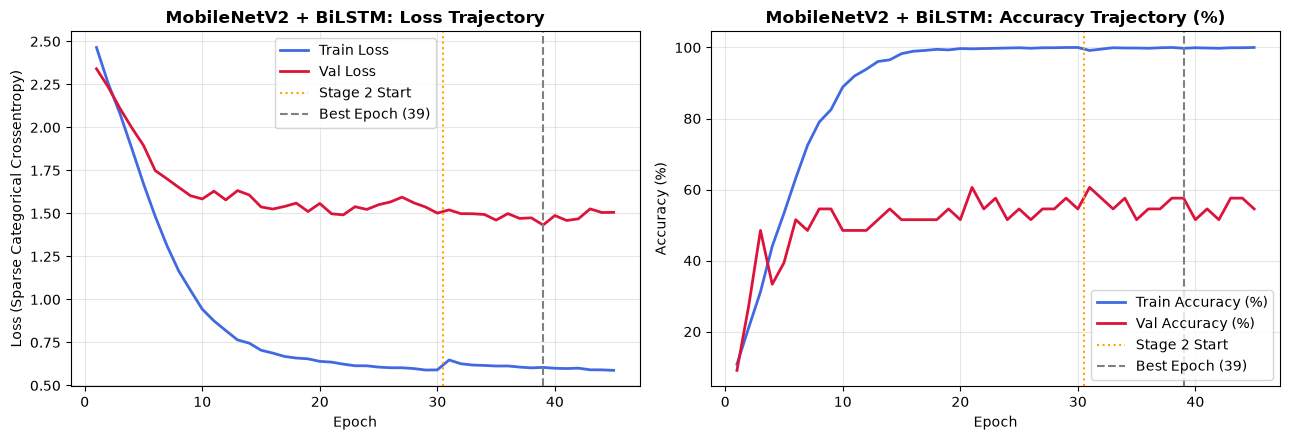

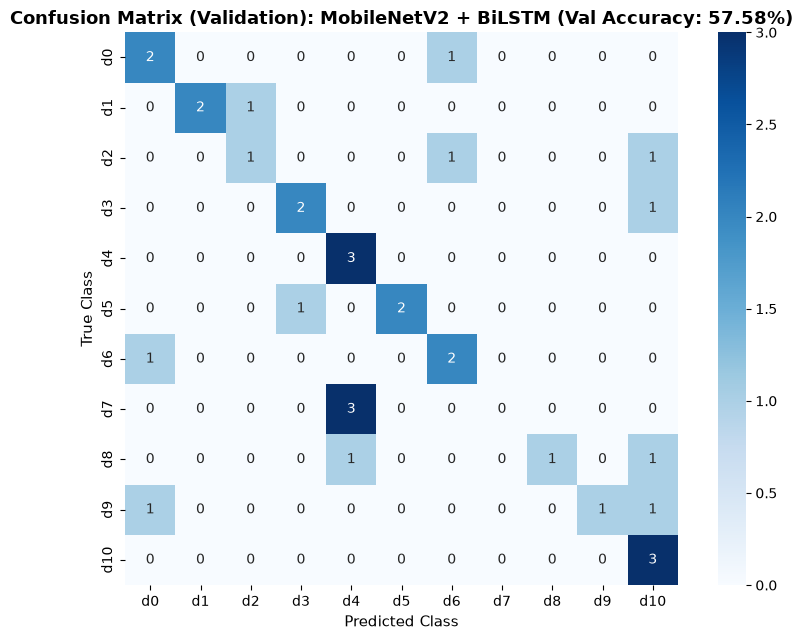

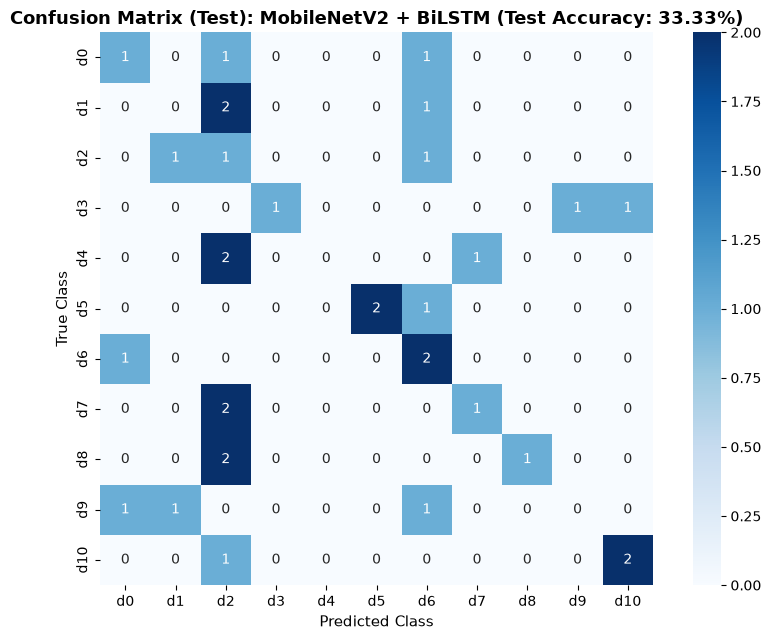


All model artifacts saved to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/mobilenetv2_bilstm


In [8]:
# Section 7: Evaluation on Unseen Test Speakers & Artifact Generation
m_name = "MobileNetV2"
slug = "mobilenetv2_bilstm"
model_dir = RESULTS_DIR / slug
model_dir.mkdir(parents=True, exist_ok=True)

# 1. Predictions on Unseen Test Speakers
print(f"\nEvaluating {m_name} + BiLSTM on {len(test_speakers)} Unseen Test Speakers...")
test_probs = model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1
)
test_preds = np.argmax(test_probs, axis=1)

test_acc = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds, average="macro", zero_division=0)
test_rec = recall_score(y_test, test_preds, average="macro", zero_division=0)
test_f1 = f1_score(y_test, test_preds, average="macro", zero_division=0)
cm = confusion_matrix(y_test, test_preds, labels=list(range(NUM_CLASSES)))

correct_count = int(np.sum(y_test == test_preds))
incorrect_count = int(np.sum(y_test != test_preds))

# 1b. Predictions on Validation Speakers & Validation Confusion Matrix
print(f"\nEvaluating {m_name} + BiLSTM on {len(val_speakers)} Validation Speakers...")
val_probs = model.predict(
    X_val,
    batch_size=BATCH_SIZE,
    verbose=1
)
val_preds = np.argmax(val_probs, axis=1)

val_acc = accuracy_score(y_val, val_preds)
val_prec = precision_score(y_val, val_preds, average="macro", zero_division=0)
val_rec = recall_score(y_val, val_preds, average="macro", zero_division=0)
val_f1 = f1_score(y_val, val_preds, average="macro", zero_division=0)
cm_val = confusion_matrix(y_val, val_preds, labels=list(range(NUM_CLASSES)))

val_correct_count = int(np.sum(y_val == val_preds))
val_incorrect_count = int(np.sum(y_val != val_preds))

# 2. Combine Two-Stage Histories for Metrics and Plots
combined_loss = history1.history["loss"] + history2.history["loss"]
combined_val_loss = history1.history["val_loss"] + history2.history["val_loss"]
combined_acc = history1.history["accuracy"] + history2.history["accuracy"]
combined_val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]

stage1_len = len(history1.history["loss"])
stage2_len = len(history2.history["loss"])
total_epochs = stage1_len + stage2_len

df_hist = pd.DataFrame({
    "epoch": range(1, total_epochs + 1),
    "stage": [1] * stage1_len + [2] * stage2_len,
    "loss": combined_loss,
    "val_loss": combined_val_loss,
    "accuracy": combined_acc,
    "val_accuracy": combined_val_acc
})
df_hist.to_csv(model_dir / "training_history.csv", index=False)

best_epoch = int(np.argmin(df_hist["val_loss"]) + 1)
best_val_loss = float(np.min(df_hist["val_loss"]))
best_val_acc = float(df_hist.loc[best_epoch - 1, "val_accuracy"])

# Save End-to-End model checkpoint
model.save(model_dir / "best_model.keras")
print(f"Saved end-to-end model checkpoint to: {model_dir / 'best_model.keras'}")

# Save classification report (Test)
report_dict = classification_report(y_test, test_preds, target_names=DIGIT_CLASSES, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv(model_dir / "per_class_metrics.csv")

# Save classification report (Validation)
report_dict_val = classification_report(y_val, val_preds, target_names=DIGIT_CLASSES, output_dict=True, zero_division=0)
df_report_val = pd.DataFrame(report_dict_val).transpose()
df_report_val.to_csv(model_dir / "per_class_metrics_val.csv")

# Model parameters
total_params = int(model.count_params())
trainable_params = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
non_trainable_params = total_params - trainable_params

# Save metrics JSON & CSV
metrics_summary = {
    "model_name": m_name + " + BiLSTM",
    "total_parameters": total_params,
    "trainable_parameters": trainable_params,
    "non_trainable_parameters": non_trainable_params,
    "stage1_epochs": stage1_len,
    "stage2_epochs": stage2_len,
    "best_epoch": best_epoch,
    "best_val_loss": round(best_val_loss, 4),
    "best_val_accuracy": round(best_val_acc, 4),
    "val_eval_accuracy": round(val_acc, 4),
    "val_eval_accuracy_pct": round(val_acc * 100, 2),
    "val_macro_precision": round(val_prec, 4),
    "val_macro_recall": round(val_rec, 4),
    "val_macro_f1": round(val_f1, 4),
    "test_accuracy": round(test_acc, 4),
    "test_accuracy_pct": round(test_acc * 100, 2),
    "test_macro_precision": round(test_prec, 4),
    "test_macro_recall": round(test_rec, 4),
    "test_macro_f1": round(test_f1, 4),
    "correct_test_predictions": correct_count,
    "incorrect_test_predictions": incorrect_count,
    "correct_val_predictions": val_correct_count,
    "incorrect_val_predictions": val_incorrect_count
}
with open(model_dir / "metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)
pd.DataFrame([metrics_summary]).to_csv(model_dir / "metrics.csv", index=False)

# Save Predictions for every test utterance
df_test_meta = df_manifest[df_manifest["split"] == "test"].copy().reset_index(drop=True)
df_test_preds = pd.DataFrame({
    "speaker": df_test_meta["speaker"],
    "true_digit": df_test_meta["digit"],
    "true_digit_id": y_test,
    "pred_digit_id": test_preds,
    "pred_digit": [ID_TO_CLASS[p] for p in test_preds],
    "is_correct": (y_test == test_preds),
    "confidence": np.max(test_probs, axis=1)
})
for c_idx, d_name in enumerate(DIGIT_CLASSES):
    df_test_preds[f"prob_{d_name}"] = test_probs[:, c_idx]
df_test_preds.to_csv(model_dir / "test_predictions.csv", index=False)

# Save Predictions for every validation utterance
df_val_meta = df_manifest[df_manifest["split"] == "val"].copy().reset_index(drop=True)
df_val_preds = pd.DataFrame({
    "speaker": df_val_meta["speaker"],
    "true_digit": df_val_meta["digit"],
    "true_digit_id": y_val,
    "pred_digit_id": val_preds,
    "pred_digit": [ID_TO_CLASS[p] for p in val_preds],
    "is_correct": (y_val == val_preds),
    "confidence": np.max(val_probs, axis=1)
})
for c_idx, d_name in enumerate(DIGIT_CLASSES):
    df_val_preds[f"prob_{d_name}"] = val_probs[:, c_idx]
df_val_preds.to_csv(model_dir / "val_predictions.csv", index=False)

# Save Confusion Matrix CSVs
df_cm = pd.DataFrame(cm, index=DIGIT_CLASSES, columns=DIGIT_CLASSES)
df_cm.to_csv(model_dir / "confusion_matrix.csv")
df_cm.to_csv(model_dir / "confusion_matrix_test.csv")

df_cm_val = pd.DataFrame(cm_val, index=DIGIT_CLASSES, columns=DIGIT_CLASSES)
df_cm_val.to_csv(model_dir / "confusion_matrix_val.csv")

# ==============================================================================
# CONSOLIDATED ALL-IN-ONE OUTPUT RESULTS (EASY TO READ AT A GLANCE)
# ==============================================================================
print("\n" + "=" * 80)
print(f"                 FINAL EVALUATION SUMMARY: {m_name.upper()} + BiLSTM")
print("=" * 80)
print(f"  Test Accuracy:           {test_acc * 100:.2f}%  ({correct_count}/{len(y_test)} correct)")
print(f"  Validation Accuracy:     {val_acc * 100:.2f}%  ({val_correct_count}/{len(y_val)} correct)")
print(f"  Best Epoch Val Accuracy: {best_val_acc * 100:.2f}%  (Best Epoch: {best_epoch})")
print(f"  Best Epoch Val Loss:     {best_val_loss:.4f}")
print(f"  Test Macro Precision:    {test_prec:.4f}")
print(f"  Test Macro Recall:       {test_rec:.4f}")
print(f"  Test Macro F1-Score:     {test_f1:.4f}")
print(f"  Total / Trainable Params:{total_params:,} / {trainable_params:,}")
print("-" * 80)
print("Per-Class Metrics (Unseen Test Speakers):")
display(df_report.loc[DIGIT_CLASSES, ["precision", "recall", "f1-score", "support"]])
print("-" * 80)
print("Per-Class Metrics (Validation Speakers):")
display(df_report_val.loc[DIGIT_CLASSES, ["precision", "recall", "f1-score", "support"]])
print("=" * 80)

# Training Curves Plot
plt.figure(figsize=(13, 4.5))
plt.subplot(1, 2, 1)
plt.plot(df_hist["epoch"], df_hist["loss"], label="Train Loss", color="royalblue", lw=2)
plt.plot(df_hist["epoch"], df_hist["val_loss"], label="Val Loss", color="crimson", lw=2)
if stage2_len > 0:
    plt.axvline(stage1_len + 0.5, color="orange", linestyle=":", label="Stage 2 Start")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
plt.title(f"{m_name} + BiLSTM: Loss Trajectory", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (Sparse Categorical Crossentropy)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(df_hist["epoch"], df_hist["accuracy"] * 100, label="Train Accuracy (%)", color="royalblue", lw=2)
plt.plot(df_hist["epoch"], df_hist["val_accuracy"] * 100, label="Val Accuracy (%)", color="crimson", lw=2)
if stage2_len > 0:
    plt.axvline(stage1_len + 0.5, color="orange", linestyle=":", label="Stage 2 Start")
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
plt.title(f"{m_name} + BiLSTM: Accuracy Trajectory (%)", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(model_dir / "training_curves.png", dpi=300)
plt.show()

# Validation Confusion Matrix Heatmap
plt.figure(figsize=(8.5, 6.5))
sns.heatmap(df_cm_val, annot=True, fmt="d", cmap="Blues", cbar=True, square=True)
plt.title(f"Confusion Matrix (Validation): {m_name} + BiLSTM (Val Accuracy: {val_acc*100:.2f}%)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("True Class", fontsize=11)
plt.tight_layout()
plt.savefig(model_dir / "confusion_matrix_val.png", dpi=300)
plt.show()

# Test Confusion Matrix Heatmap
plt.figure(figsize=(8.5, 6.5))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True)
plt.title(f"Confusion Matrix (Test): {m_name} + BiLSTM (Test Accuracy: {test_acc*100:.2f}%)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("True Class", fontsize=11)
plt.tight_layout()
plt.savefig(model_dir / "confusion_matrix.png", dpi=300)
plt.savefig(model_dir / "confusion_matrix_test.png", dpi=300)
plt.show()

print(f"\nAll model artifacts saved to: {model_dir.resolve()}")
